In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from graph_config import *

In [2]:
adjacency = pd.read_csv('../Data/adjacency_matrix.csv', index_col=0)
state_names = adjacency.columns.tolist()
A = adjacency.to_numpy()
n = len(A)

In [3]:
I = np.random.normal(loc=0.1,scale=0.01,size=n) # random initial
beta = 0.4
gamma = 0.3
t = 0
dt = 0.01
t_list = []
I_list = []
while t<30:
    dI_dt = -gamma*I + beta*np.dot(A,I)*(1-I)
    I = I + dt*dI_dt
    t = t + dt
    t_list.append(t)
    I_list.append(I.copy())

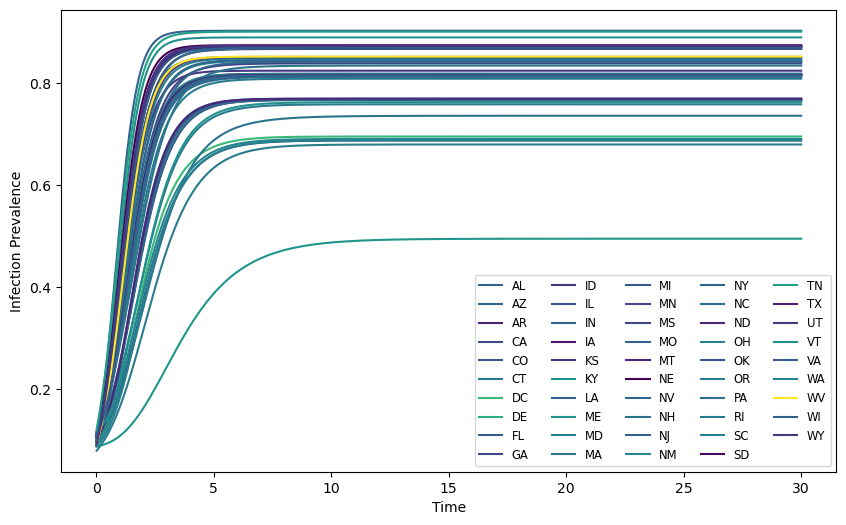

In [11]:
states = list(state_abbr.keys())
opioid = opioid_data.loc[states].copy()
opioid.index = list(state_abbr_rev.keys())
values = opioid['2023'].values
norm = plt.Normalize(min(values), max(values))
cmap = plt.cm.viridis
colors = [cmap(norm(val)) for val in values]
t_list = np.asarray(t_list)
I_list = np.asarray(I_list)
plt.figure(figsize=(10,6))
for i in range(49):
    plt.plot(t_list, I_list[:,i], color = colors[i])
plt.xlabel('Time')
plt.ylabel('Infection Prevalence')
plt.legend(state_names, loc='lower right', fontsize='small', ncol=5)
plt.show()